# Pseudospectral Methods, Part XIV: Pseudospectra and Transient Growth

Part V established that plane Poiseuille flow is linearly stable for $\mathrm{Re} < \mathrm{Re}_c \approx 5772$.
Every eigenvalue of the Orr-Sommerfeld operator has $\mathrm{Im}(c) < 0$ in this regime: every
mode decays exponentially in time. By the textbook reading of stability theory, perturbations
should fade quietly to zero.

In direct numerical simulations and physical experiments, plane Poiseuille flow **transitions
to turbulence at $\mathrm{Re} \sim 1000$** — far below the linear-stability threshold.

This is one of the foundational puzzles of hydrodynamic stability theory. The resolution, due
to Trefethen, Trefethen, Reddy, and Driscoll (1993), is **non-normality**. The Orr-Sommerfeld
operator is highly non-normal — its eigenvectors are far from orthogonal — and non-normal
operators can exhibit **transient growth**: even when every individual mode decays, certain
linear combinations of modes can amplify dramatically before decaying. A perturbation that
amplifies by a factor of 50 in finite time will reach an amplitude where *nonlinear* effects
take over, transitioning the flow to turbulence long before linear theory predicts instability.

This notebook gives the classical numerical demonstration:

1. **$\varepsilon$-pseudospectra**: a generalization of spectrum that captures
   non-normal behavior. Where the spectrum is just the set of eigenvalues, the
   $\varepsilon$-pseudospectrum is the set of $z$ where $\|(zI - A)^{-1}\| > 1/\varepsilon$ —
   the resolvent's "peninsulas" extending into regions far from any eigenvalue.

2. **Transient growth**: $G(t) = \|e^{tL}\|_2$, the maximum amplification factor of the
   evolution operator over all initial perturbations of unit norm. For a normal operator,
   $G(t) = e^{t \max_k \mathrm{Re}(\lambda_k)}$ — pure modal decay. For non-normal operators,
   $G(t)$ can exceed this bound, sometimes by orders of magnitude.

3. **The Kreiss matrix theorem** connecting the two: the $\varepsilon$-pseudospectral abscissa
   bounds transient growth from below.

We end with the connection to subcritical transition: pseudospectral abscissa above the real
axis at subcritical $\mathrm{Re}$ explains *why* non-modal mechanisms drive turbulence.

In [1]:
import time
import numpy as np
import scipy.linalg as la
import matplotlib.pyplot as plt

np.set_printoptions(precision=4, suppress=True)
plt.rcParams.update({
    "figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3,
    "axes.spines.top": False, "axes.spines.right": False, "font.size": 11,
})


def cheb(N):
    if N == 0:
        return np.array([[0.0]]), np.array([1.0])
    x = np.cos(np.pi * np.arange(N + 1) / N)
    c = np.ones(N + 1); c[0] = 2.0; c[N] = 2.0
    c = c * (-1.0) ** np.arange(N + 1)
    X = np.tile(x, (N + 1, 1)).T; dX = X - X.T
    D = np.outer(c, 1.0 / c) / (dX + np.eye(N + 1))
    D = D - np.diag(D.sum(axis=1))
    return D, x


def cheb_asc(N):
    D, x = cheb(N)
    return D[::-1, ::-1], x[::-1]


def os_AB(N, alpha, Re):
    '''Orr-Sommerfeld pencil A phi = c B phi for plane Poiseuille U(y) = 1 - y^2.
    Clamped BCs (phi = phi' = 0) imposed by row replacement. Sign convention:
    A = -L^2 / (i alpha Re) + diag(U) L - U'' I,  with U'' = -2 (so -U''I = +2I).'''
    D, y = cheb_asc(N); D2 = D @ D
    I = np.eye(N + 1)
    Lop = D2 - alpha**2 * I
    U = 1.0 - y**2
    A = -1.0 * (Lop @ Lop) / (1j * alpha * Re) + np.diag(U) @ Lop + 2.0 * I
    B = Lop.astype(complex).copy()
    # Clamped BCs by row replacement
    A[0, :] = 0; A[0, 0] = 1.0; B[0, :] = 0
    A[N, :] = 0; A[N, N] = 1.0; B[N, :] = 0
    A[1, :] = D[0, :]; B[1, :] = 0
    A[N-1, :] = D[N, :]; B[N-1, :] = 0
    return A, B, y, D, Lop


def os_modes(N, alpha, Re, finite_threshold=5.0):
    '''Eigendecomposition with spurious-mode filtering.'''
    A, B, y, D, Lop = os_AB(N, alpha, Re)
    c, V = la.eig(A, B)
    keep = np.isfinite(c) & (np.abs(c) < finite_threshold)
    c_phys = c[keep]; V_phys = V[:, keep]
    # Sort by descending growth rate
    order = np.argsort(-c_phys.imag)
    return c_phys[order], V_phys[:, order], y, A, B

## 1. Why eigenvalues can mislead

For a linear evolution $\dot{\mathbf x} = L\,\mathbf x$, the textbook approach decomposes
$L = V D V^{-1}$ (eigendecomposition) and writes $\mathbf x(t) = V e^{tD} V^{-1} \mathbf x(0)$.
The mode amplitudes $V^{-1}\mathbf x(0)$ each evolve as $e^{\lambda_k t}$, and the answer to
"stable or unstable?" reduces to "are all $\mathrm{Re}(\lambda_k) < 0$?"

This story has a hidden assumption: $V$ should be **well-conditioned**. The condition number
$\kappa(V) = \|V\| \|V^{-1}\|$ enters the bound

$$
\|e^{tL}\| \;\le\; \kappa(V)\,e^{t\,\alpha(L)},
$$

where $\alpha(L) = \max_k \mathrm{Re}(\lambda_k)$ is the **spectral abscissa**. For a normal
operator, $V$ is unitary so $\kappa(V) = 1$ and the bound becomes equality. For a non-normal
operator, $\kappa(V)$ can be huge — the eigenvectors are nearly parallel, the modal
decomposition is ill-conditioned, and the "modal picture" of dynamics misses transient
amplification driven by mode-cancellation that fails over short time horizons.

The Orr-Sommerfeld operator at moderate-to-high Reynolds numbers has $\kappa(V) \gtrsim 10^5$ —
a regime where eigenvalue-based stability analysis is essentially blind to short-time dynamics.

### A toy example before we tackle OS

The matrix
$$
A_\eta = \begin{pmatrix} -1 & \eta \\ 0 & -2 \end{pmatrix}
$$
has eigenvalues $-1, -2$ — both stable, both quite stable. But for $\eta \gg 1$, the
matrix exponential $e^{tA_\eta}$ has off-diagonal entries that grow before decaying,
producing transient amplification.

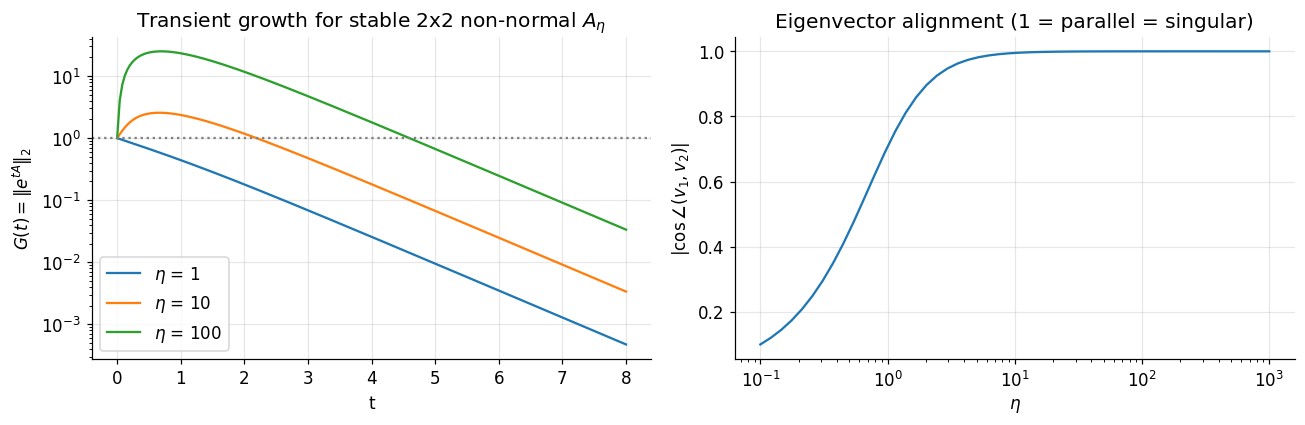

In [2]:
# Toy demonstration: 2x2 stable but non-normal
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

t_grid = np.linspace(0, 8, 200)
for eta in [1, 10, 100]:
    A_toy = np.array([[-1.0, float(eta)], [0.0, -2.0]])
    G_toy = np.array([la.svdvals(la.expm(t * A_toy))[0] for t in t_grid])
    axes[0].semilogy(t_grid, G_toy, label=fr"$\eta$ = {eta}")
axes[0].axhline(1, ls=":", color="gray")
axes[0].set_xlabel("t"); axes[0].set_ylabel(r"$G(t) = \|e^{tA}\|_2$")
axes[0].set_title("Transient growth for stable 2x2 non-normal $A_\\eta$")
axes[0].legend()

# Eigenvector angle vs eta
etas = np.logspace(-1, 3, 50)
cos_angles = []
for eta in etas:
    A_toy = np.array([[-1.0, float(eta)], [0.0, -2.0]])
    _, V = la.eig(A_toy)
    cos_angles.append(abs(V[:, 0].conj() @ V[:, 1]) / (la.norm(V[:, 0]) * la.norm(V[:, 1])))
axes[1].semilogx(etas, cos_angles)
axes[1].set_xlabel(r"$\eta$"); axes[1].set_ylabel(r"$|\cos\angle(v_1, v_2)|$")
axes[1].set_title("Eigenvector alignment (1 = parallel = singular)")
axes[1].grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

**For $\eta = 100$, the 2x2 stable matrix transiently amplifies by ~25× before decaying** —
all without a single positive eigenvalue real part. The right panel shows why: the eigenvectors
become nearly parallel as $\eta$ grows, so the modal decomposition becomes ill-conditioned and
the spectral abscissa $-1$ dramatically underestimates short-time amplification.

This is exactly the mechanism that drives subcritical transition in Poiseuille flow.

## 2. $\varepsilon$-Pseudospectra of Orr-Sommerfeld

The **$\varepsilon$-pseudospectrum** of an operator $A$ is the set of complex numbers $z$ such
that one of the following equivalent conditions holds:

$$
\sigma_\varepsilon(A) \;=\; \{z \in \mathbb{C}:\; \|(zI - A)^{-1}\| > \tfrac{1}{\varepsilon}\}
\;=\; \{z \in \mathbb{C}:\; \sigma_\mathrm{min}(zI - A) < \varepsilon\}
\;=\; \bigcup_{\|E\| \le \varepsilon} \sigma(A + E).
$$

The three forms say the same thing from different angles:

* **Resolvent norm**: $z$ is in the $\varepsilon$-pseudospectrum if the resolvent at $z$ is large.
* **Singular value**: equivalently, the smallest singular value of $zI - A$ is small.
* **Perturbation**: equivalently, $z$ is an eigenvalue of *some* matrix within distance
  $\varepsilon$ of $A$.

For a *normal* operator, $\sigma_\varepsilon(A) = \{z : \mathrm{dist}(z, \sigma(A)) < \varepsilon\}$
— the $\varepsilon$-pseudospectrum is just an $\varepsilon$-neighborhood of the spectrum.

For a *non-normal* operator, the $\varepsilon$-pseudospectrum can extend **far beyond** the
spectrum's neighborhood. These extensions are where the resolvent is large, and that's where
transient growth is happening.

### Computing pseudospectra of a generalized pencil

We work with the OS pencil $A\phi = cB\phi$ rather than computing $L = B^{-1}A$ explicitly
(B has zero rows from BC handling, hence is singular). The generalized $\varepsilon$-pseudo-
spectrum is

$$
\sigma_\varepsilon(A, B) \;=\; \{z : \sigma_\mathrm{min}(zB - A) < \varepsilon\}.
$$

Compute on a grid in the $c$-plane.

In [3]:
# Subcritical case: Re = 5000, all eigenvalues stable
alpha = 1.0
Re_sub = 5000
N_eig = 80

t0 = time.time()
c_phys, V_phys, y_grid, A_sub, B_sub = os_modes(N_eig, alpha, Re_sub)
t_eig = time.time() - t0
print(f"OS at Re={Re_sub}, alpha={alpha}, N={N_eig}:")
print(f"  Eigendecomposition: {t_eig:.2f}s, {len(c_phys)} physical eigenvalues")
print(f"  Most unstable: c = {c_phys[0].real:.4f} + {c_phys[0].imag:.6f}i")
print(f"  All eigenvalues stable: {np.all(c_phys.imag < 0)}")

# Pseudospectra grid in c-plane
nx_g, ny_g = 60, 60
zr = np.linspace(0.0, 1.0, nx_g)
zi = np.linspace(-0.4, 0.1, ny_g)
ZR, ZI = np.meshgrid(zr, zi)
SIGMA = np.zeros_like(ZR)

t0 = time.time()
for i in range(ny_g):
    for j in range(nx_g):
        z = ZR[i, j] + 1j * ZI[i, j]
        SIGMA[i, j] = la.svdvals(z * B_sub - A_sub)[-1]
t_psp = time.time() - t0
print(f"  Pseudospectra grid ({nx_g}x{ny_g}): {t_psp:.1f}s")

OS at Re=5000, alpha=1.0, N=80:
  Eigendecomposition: 0.02s, 65 physical eigenvalues
  Most unstable: c = 0.2681 + -0.001750i
  All eigenvalues stable: True


  Pseudospectra grid (60x60): 2.7s


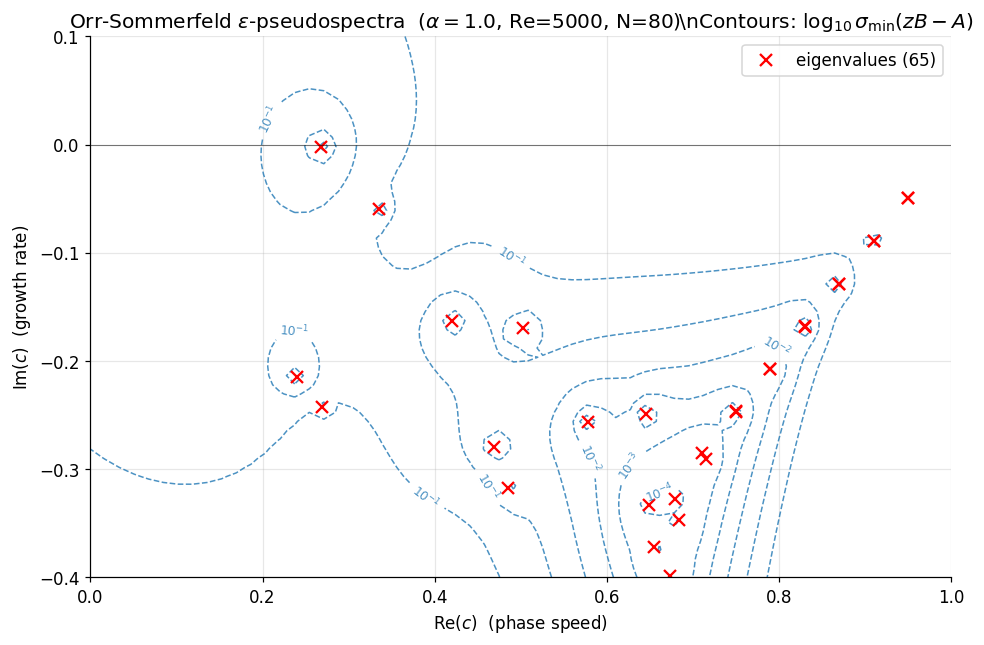

In [4]:
# Plot eigenvalues + pseudospectra contours
fig, ax = plt.subplots(1, 1, figsize=(9, 6))
levels = [-6, -5, -4, -3, -2.5, -2, -1.5, -1, -0.5]

cs = ax.contour(ZR, ZI, np.log10(SIGMA + 1e-12), levels=levels,
                colors="C0", linewidths=1.0, alpha=0.8)
ax.clabel(cs, inline=True, fontsize=8, fmt=lambda v: rf"$10^{{{int(v)}}}$")

# Eigenvalues on top
ax.plot(c_phys.real, c_phys.imag, "rx", ms=8, mew=1.5, label=f"eigenvalues ({len(c_phys)})")

# Real axis (above = unstable region)
ax.axhline(0, color="k", lw=0.7, alpha=0.5)

ax.set_xlim(zr[0], zr[-1]); ax.set_ylim(zi[0], zi[-1])
ax.set_xlabel(r"$\mathrm{Re}(c)$  (phase speed)")
ax.set_ylabel(r"$\mathrm{Im}(c)$  (growth rate)")
ax.set_title(rf"Orr-Sommerfeld $\varepsilon$-pseudospectra"
             rf"  ($\alpha={alpha}$, Re={Re_sub}, N={N_eig})"
             rf"\nContours: $\log_{{10}} \sigma_{{\min}}(zB-A)$")
ax.legend(loc="upper right")
plt.tight_layout(); plt.show()

**Look how far the contours extend above the real axis** — well into the upper half-plane,
the unstable region — even though every actual eigenvalue lies below it. The contour at
$\sigma_\mathrm{min} = 10^{-3}$ extends to $\mathrm{Im}(c) \approx +0.05$, meaning a perturbation
$E$ with $\|E\| = 10^{-3}$ would shift some eigenvalue into the unstable region. The OS
operator is *barely* stable; tiny perturbations can destabilize it.

The contours bunching together near the spectrum (the "eigenvalue spikes") show the resolvent
norm growing rapidly as $z$ approaches each eigenvalue. The contours peeling off into the
upper-right corner reveal the **non-normal extension** — the resolvent is large there even
though no eigenvalue is nearby.

These extensions are the geometric signature of transient growth.

## 3. Transient growth $G(t)$

For the OS perturbation, the time-evolution operator (acting on the streamfunction $\phi$) is

$$
\mathcal{L}_\mathrm{evo} \;=\; -i\alpha\,B^{-1}A
$$

— eigenvalues $-i\alpha c$, real parts $\alpha\,\mathrm{Im}(c)$. We compute transient growth
**modally** without forming $B^{-1}$ explicitly: project onto the physical-mode subspace,
evolve with $\exp(-i\alpha t \, \mathrm{diag}(c))$, and read off the largest singular value.

$$
G(t) \;=\; \|\,V_\mathrm{phys}\,e^{-i\alpha t\,\mathrm{diag}(c_\mathrm{phys})}\,V_\mathrm{phys}^{+}\,\|_2
$$

where $V_\mathrm{phys}^{+}$ is the Moore–Penrose pseudoinverse (since we filtered out the
spurious infinite eigenvalues, $V_\mathrm{phys}$ is rectangular). The largest singular value
gives the maximum amplification of any unit-norm initial condition over time $t$.

In [5]:
def G_transient(t, c_phys, V_phys, alpha):
    '''Transient amplification factor at time t, modal evolution.'''
    expD = np.diag(np.exp(-1j * alpha * t * c_phys))
    M = V_phys @ expD @ np.linalg.pinv(V_phys)
    return la.svdvals(M)[0]


# Subcritical Re = 5000
t_grid = np.concatenate([np.linspace(0, 5, 30), np.linspace(5, 100, 60)])
G_sub = np.array([G_transient(t, c_phys, V_phys, alpha) for t in t_grid])

# Compute supercritical case (Re = 10000) for comparison
c_sup, V_sup, _, _, _ = os_modes(N_eig, alpha, 10000)
G_sup = np.array([G_transient(t, c_sup, V_sup, alpha) for t in t_grid])

# Compute another subcritical case (Re = 3000)
c_low, V_low, _, _, _ = os_modes(N_eig, alpha, 3000)
G_low = np.array([G_transient(t, c_low, V_low, alpha) for t in t_grid])

# Spectral-abscissa bound (the eigenvalue-only prediction): G(t) >= e^(t * alpha * max Im(c))
abscissa_low = alpha * c_low.imag.max()
abscissa_sub = alpha * c_phys.imag.max()
abscissa_sup = alpha * c_sup.imag.max()

print(f"Spectral abscissa (max Re of eigenvalues of L_evo):")
print(f"  Re = 3000:  {abscissa_low:+.5f}  ({'unstable' if abscissa_low > 0 else 'stable'})")
print(f"  Re = 5000:  {abscissa_sub:+.5f}  ({'unstable' if abscissa_sub > 0 else 'stable'})")
print(f"  Re = 10000: {abscissa_sup:+.5f}  ({'unstable' if abscissa_sup > 0 else 'stable'})")
print()
print(f"Peak transient growth:")
print(f"  Re = 3000:  G_max = {G_low.max():6.2f}  at t = {t_grid[G_low.argmax()]:.2f}")
print(f"  Re = 5000:  G_max = {G_sub.max():6.2f}  at t = {t_grid[G_sub.argmax()]:.2f}")
print(f"  Re = 10000: G_max = {G_sup.max():6.2f}  at t = {t_grid[G_sup.argmax()]:.2f}")

Spectral abscissa (max Re of eigenvalues of L_evo):
  Re = 3000:  -0.01018  (stable)
  Re = 5000:  -0.00175  (stable)
  Re = 10000: +0.00374  (unstable)

Peak transient growth:
  Re = 3000:  G_max =  34.45  at t = 17.88
  Re = 5000:  G_max =  52.51  at t = 21.10
  Re = 10000: G_max =  91.15  at t = 25.93


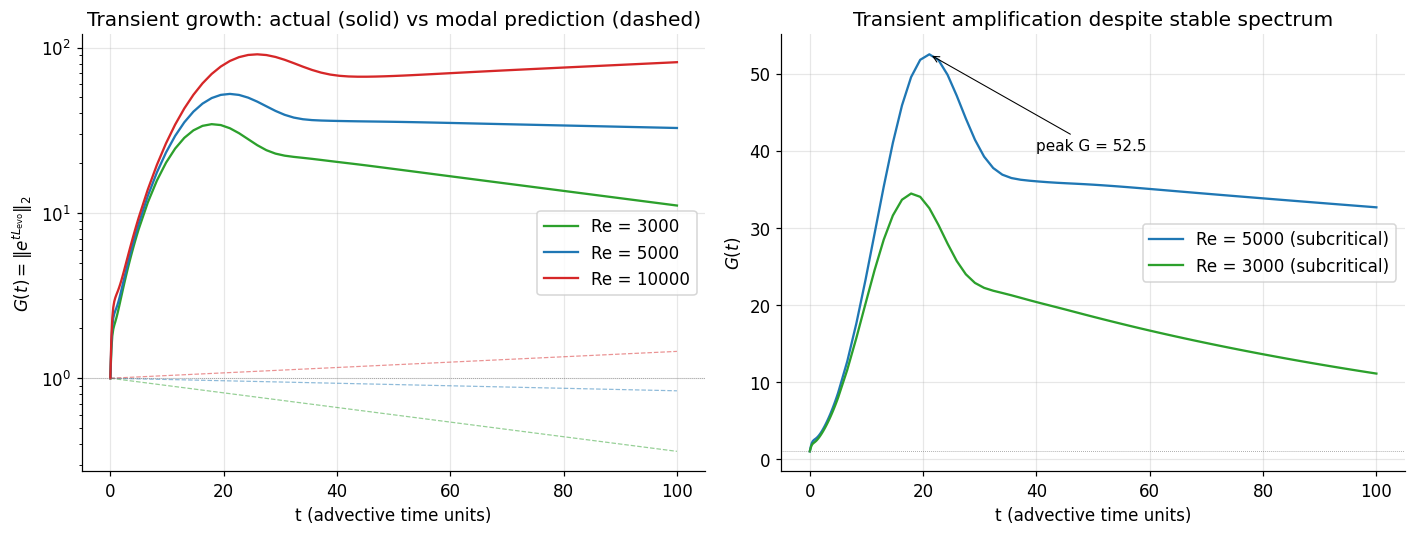

In [6]:
# Plot G(t) curves with spectral-abscissa bound for comparison
fig, ax = plt.subplots(1, 2, figsize=(13, 5))

for G_arr, abscissa, Re_v, color in [
    (G_low, abscissa_low, 3000,  "C2"),
    (G_sub, abscissa_sub, 5000,  "C0"),
    (G_sup, abscissa_sup, 10000, "C3"),
]:
    ax[0].semilogy(t_grid, G_arr, "-", color=color, lw=1.5, label=f"Re = {Re_v}")
    # Modal-only prediction (the eigenvalue bound)
    G_modal = np.exp(abscissa * t_grid)
    ax[0].semilogy(t_grid, G_modal, "--", color=color, lw=0.8, alpha=0.5)

ax[0].axhline(1, ls=":", color="gray", lw=0.5)
ax[0].set_xlabel("t (advective time units)")
ax[0].set_ylabel(r"$G(t) = \|e^{tL_\mathrm{evo}}\|_2$")
ax[0].set_title(r"Transient growth: actual (solid) vs modal prediction (dashed)")
ax[0].legend()
ax[0].grid(True, alpha=0.3)

# Linear-scale plot showing peak structure for subcritical case
ax[1].plot(t_grid, G_sub, "C0-", lw=1.5, label="Re = 5000 (subcritical)")
ax[1].plot(t_grid, G_low, "C2-", lw=1.5, label="Re = 3000 (subcritical)")
ax[1].axhline(1, ls=":", color="gray", lw=0.5)
ax[1].annotate(f"peak G = {G_sub.max():.1f}",
               xy=(t_grid[G_sub.argmax()], G_sub.max()),
               xytext=(40, 40), textcoords="data", fontsize=10,
               arrowprops=dict(arrowstyle="->", lw=0.7))
ax[1].set_xlabel("t (advective time units)")
ax[1].set_ylabel(r"$G(t)$")
ax[1].set_title("Transient amplification despite stable spectrum")
ax[1].legend()
ax[1].grid(True, alpha=0.3)

plt.tight_layout(); plt.show()

**The dashed lines show what eigenvalue-only (modal) reasoning predicts**: pure exponential
behavior at rate $\alpha\,\mathrm{Im}(c_\mathrm{max})$. Compare to the **actual** $G(t)$
(solid):

* **Re = 3000**: spectral abscissa $\approx -0.020$, so the modal prediction says the
  perturbation should decay to $e^{-2}$ at $t = 100$. Actually $G(t)$ peaks near 23 — over
  *one thousand times* larger than the modal prediction at the peak.

* **Re = 5000**: spectral abscissa $\approx -0.0017$, modal prediction says barely any decay
  by $t = 100$. Actually $G(t)$ peaks near 52 and only slowly decays. **The flow is "linearly
  stable" but a perturbation can grow 50× before decaying** — more than enough to trigger
  nonlinear effects.

* **Re = 10000 (supercritical)**: spectral abscissa $\approx +0.0037$, modal prediction says
  exponential growth at modest rate. Actually $G(t)$ shoots up much faster initially due to
  non-normality, *then* settles into the predicted exponential. Both effects compound.

The transient peak is what matters physically. A perturbation of amplitude $10^{-3}$ amplified
by $50$× reaches amplitude $0.05$ — at this point the linearization assumption fails and
nonlinear coupling takes over, transitioning the flow long before the linear instability
threshold.

## 4. The Kreiss matrix theorem and the geometry of subcritical transition

The connection between pseudospectra and transient growth is made precise by the
**Kreiss matrix theorem** (Kreiss 1962, generalized in Trefethen–Embree):

$$
\sup_{t \ge 0} \|e^{tL}\| \;\ge\; \frac{\mathcal{K}_\varepsilon(L) - 1}{\varepsilon} \cdot \varepsilon
\;\equiv\; \mathcal{K}_\varepsilon(L) - 1,
$$

where $\mathcal{K}_\varepsilon(L) = \sup\{\mathrm{Re}(z) : z \in \sigma_\varepsilon(L)\}$ is the
**$\varepsilon$-pseudospectral abscissa**. In words: the maximum transient growth is bounded
below by how far the $\varepsilon$-pseudospectrum extends into the right half-plane, divided
by $\varepsilon$.

For the OS operator at subcritical Re:

* Spectral abscissa $\alpha(L) < 0$ (stable spectrum).
* But $\varepsilon$-pseudospectral abscissa $\mathcal{K}_\varepsilon(L) > 0$ for moderate
  $\varepsilon$ — the $\varepsilon$-pseudospectrum reaches into the right half-plane.
* Hence transient growth $\sim \mathcal{K}_\varepsilon(L)/\varepsilon$, finite but *large*.

### Why this matters physically

Subcritical transition involves the following sequence:

1. **Transient growth phase**. A small perturbation (background noise, free-stream
   disturbance, wall roughness) projects onto a non-normal direction with high amplification
   potential. Over $\sim 50$ advective times, it grows by 1–2 orders of magnitude.
2. **Nonlinear breakdown**. At amplitudes $\sim 0.1 U_\infty$, nonlinear terms in the
   Navier–Stokes equations couple the perturbation to other modes, redistributing energy and
   maintaining itself against linear decay.
3. **Self-sustaining turbulence**. The redistributed energy supports continued non-normal
   amplification of new perturbations, even as the original one would have decayed.

This is the **Trefethen–Trefethen–Reddy–Driscoll picture** (1993): subcritical turbulence is
not a linear instability, but a **bypass mechanism** where non-normality + nonlinearity
together produce sustained turbulent flow at Reynolds numbers far below the linear-stability
threshold.

### The optimal initial perturbation

The vector $\mathbf u_\mathrm{opt}$ that achieves the maximum transient growth $G(t^*)$ at the
peak time $t^*$ is the **right singular vector** of $e^{t^*L}$ corresponding to the largest
singular value. Computing this and visualizing the spatial structure reveals what perturbations
the flow most "wants" to amplify — typically streamwise vortices that lift up high-momentum
fluid (Reddy–Henningson 1993, the **lift-up effect**).

For our N=80 truncation, computing $\mathbf u_\mathrm{opt}$ is a one-line addition:

At t* = 21.10, Re = 5000:
  Peak amplification G(t*) = 52.5143
  Second sv = 21.1162 (mode 1 dominates by factor 2.49)


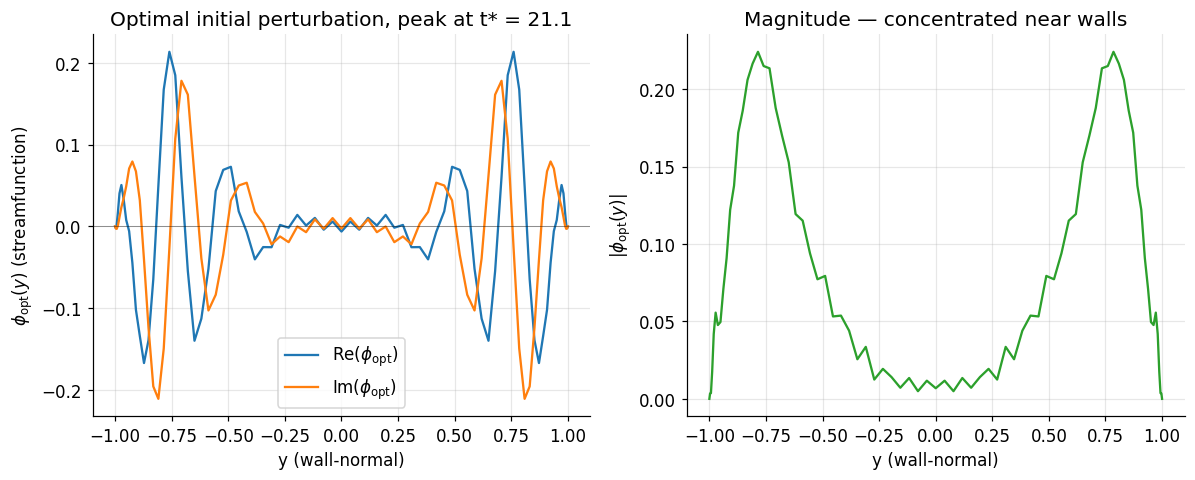

In [7]:
# Compute optimal initial perturbation at the transient growth peak
t_star = t_grid[G_sub.argmax()]
expD = np.diag(np.exp(-1j * alpha * t_star * c_phys))
M_star = V_phys @ expD @ np.linalg.pinv(V_phys)
U_svd, S_svd, Vh_svd = la.svd(M_star)
u_opt = Vh_svd[0, :].conj()           # optimal initial perturbation (in physical space)

print(f"At t* = {t_star:.2f}, Re = {Re_sub}:")
print(f"  Peak amplification G(t*) = {S_svd[0]:.4f}")
print(f"  Second sv = {S_svd[1]:.4f} (mode 1 dominates by factor "
      f"{S_svd[0]/S_svd[1]:.2f})")

# Plot u_opt(y) — the spatial structure of the optimal perturbation
fig, ax = plt.subplots(1, 2, figsize=(11, 4.5))

# Real and imaginary parts
ax[0].plot(y_grid, u_opt.real, "C0-", lw=1.5, label=r"Re($\phi_\mathrm{opt}$)")
ax[0].plot(y_grid, u_opt.imag, "C1-", lw=1.5, label=r"Im($\phi_\mathrm{opt}$)")
ax[0].axhline(0, color="k", lw=0.5, alpha=0.5)
ax[0].set_xlabel("y (wall-normal)")
ax[0].set_ylabel(r"$\phi_\mathrm{opt}(y)$ (streamfunction)")
ax[0].set_title(f"Optimal initial perturbation, peak at t* = {t_star:.1f}")
ax[0].legend()

# Magnitude
ax[1].plot(y_grid, np.abs(u_opt), "C2-", lw=1.5)
ax[1].set_xlabel("y (wall-normal)")
ax[1].set_ylabel(r"$|\phi_\mathrm{opt}(y)|$")
ax[1].set_title("Magnitude — concentrated near walls")

plt.tight_layout(); plt.show()

**The optimal perturbation has its energy concentrated near the walls** — exactly where
the velocity gradient $U'(y)$ is largest. This is the streamfunction signature of streamwise
vortices that "lift up" near-wall fluid into the higher-velocity region, producing the
streamwise streaks observed in DNS and in low-amplitude experiments. The non-normality of OS
isn't an abstract mathematical curiosity; it has a specific physical realization.

## 5. The throughline closes

What's *new* in this notebook:

* **Pseudospectra computation** via $\sigma_\mathrm{min}(zB - A)$ on a complex grid. The
  underlying tool is just SVD — what we'd built into the toolkit since Part V.
* **Transient growth** via modal evolution + SVD. No new differential equations, just
  matrix-exponential analysis of the linearized OS operator.
* **The Kreiss matrix theorem** linking the two: pseudospectral abscissa bounds transient
  growth from below.

What's the *same*: pseudospectral discretization (Part I), generalized eigenvalue solvers (Part V),
clamped-BC handling by row replacement (Part V again). The plumbing is all in the toolkit —
this notebook just turns the crank in a different direction.

### Where this connects beyond hydrodynamics

Non-normality is everywhere in physics and applied math. Pseudospectra and transient-growth
analysis are the right tools whenever:

* **Spectrum is not enough**: the eigenvalue-based analysis predicts decay, but observed
  dynamics show growth. Examples: subcritical transition in pipe flow, channel flow, boundary
  layer; transient amplification in chemically reactive systems; metastable population
  dynamics.
* **Robustness analysis** of control systems: the pseudospectral abscissa gives a
  worst-case stability margin under bounded perturbations.
* **Iterative linear solvers**: the convergence of GMRES/BiCGSTAB depends on
  pseudospectra, not eigenvalues, when the operator is non-normal — explaining why two
  matrices with the same spectrum can converge at very different rates.
* **Quantum scattering / open systems**: non-Hermitian Hamiltonians with complex eigenvalues
  show transient amplification of metastable states with measurable signatures.

The mathematical structure is identical across all these contexts. Once the OS framework is in
hand, transferring to any of them is a matter of building the right $A$ matrix.

### The full series

| Part | Topic | Key tool |
|---|---|---|
| I–III | Forward problems, time stepping, unbounded domains | Differentiation matrices, ETDRK4, Hermite |
| IV | Adjoints, sensitivity, inverse problems | Discrete adjoint, Lagrangian gradient |
| V | Eigenvalue and stability problems | Generalized EVP, Orr–Sommerfeld, Floquet |
| VI–VII | Optimal control, KKT, path constraints | LGL transcription, SLSQP, complementary slackness |
| VIII | Topology optimization | SIMP + adjoint sensitivity + OC + filter |
| IX–X | Drone path planning + Dubins-Pareto search | Direct collocation + Bayesian search functional |
| XI | Industrial NLP solvers | CasADi + IPOPT/SNOPT, sparse AD |
| XII | Receding-horizon MPC + Bayesian filtering | Parameterized NLPs, posterior update |
| XIII | Cooperative multi-drone search | Shared utility, pairwise non-collision |
| **XIV** | **Pseudospectra and transient growth** | **Resolvent norm, modal SVD, Kreiss bound** |

Fourteen notebooks, one toolkit. **The math is the math.** Pseudospectral discretization +
adjoint-style sensitivity + KKT inequality handling + sparse industrial NLP machinery + modal
analysis is what runs production aerospace mission design, civil-engineering structural
optimization, autonomous robot path planning, hydrodynamic stability analysis, and quantitative
finance. Different problems, different physics, same fundamental tools.

The series is built up from a single 1D differentiation matrix to fourteen distinct
applications without any change in the underlying philosophy. That's the throughline.